In [ ]:
!pip install pandas scikit-learn matplotlib joblib --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import joblib

In [4]:
from google.colab import files
uploaded = files.upload()

Saving mingguan_laporan_total_saldo_bank_sampah_2025.csv to mingguan_laporan_total_saldo_bank_sampah_2025.csv


In [5]:
filename = list(uploaded.keys())[0]
df_raw = pd.read_csv(filename, header=2)

df_raw.head()

,Bulan,Nilai
0,Jan 1 2025,2457495
1,Jan 8 2025,2170972
2,Jan 15 2025,1653308
3,Jan 22 2025,1639236
4,Feb 1 2025,2660635


In [6]:
# buang baris yang tidak punya bulan atau saldo
df = df_raw.dropna()

# rename kolom agar konsisten
df = df.rename(columns={
    'Bulan': 'tanggal',
    'Nilai': 'saldo'
})

# Pastikan nama kolom sesuai
df.columns = ['tanggal', 'saldo']

# Konversi ke datetime
df['tanggal'] = pd.to_datetime(df['tanggal'], format='%b %d %Y')

# Urutkan berdasarkan waktu
df = df.sort_values('tanggal').reset_index(drop=True)

df[['tanggal', 'saldo']].head()

,tanggal,saldo
0,2025-01-01,2457495
1,2025-01-08,2170972
2,2025-01-15,1653308
3,2025-01-22,1639236
4,2025-02-01,2660635


In [7]:
df['minggu_ke'] = np.arange(len(df))  # urutan minggu
df['bulan'] = df['tanggal'].dt.month
df['minggu_dalam_bulan'] = df['tanggal'].dt.day // 7 + 1


In [8]:
# Membuat fitur lag (saldo minggu sebelumnya)
df['lag_1'] = df['saldo'].shift(1)
df['lag_2'] = df['saldo'].shift(2)
df['lag_3'] = df['saldo'].shift(3)

# Moving average
df['ma_4'] = df['saldo'].rolling(window=4).mean()

df = df.dropna().reset_index(drop=True)
df.head()

,tanggal,saldo,minggu_ke,bulan,minggu_dalam_bulan,lag_1,lag_2,lag_3,ma_4
0,2025-01-22,1639236,3,1,4,1653308.0,2170972.0,2457495.0,1980252.75
1,2025-02-01,2660635,4,2,1,1639236.0,1653308.0,2170972.0,2031037.75
2,2025-02-08,806269,5,2,2,2660635.0,1639236.0,1653308.0,1689862.00
3,2025-02-15,2273683,6,2,3,806269.0,2660635.0,1639236.0,1844955.75
4,2025-02-22,1083527,7,2,4,2273683.0,806269.0,2660635.0,1706028.50


In [9]:
features = ['lag_1', 'lag_2', 'lag_3', 'ma_4', 'bulan', 'minggu_dalam_bulan']

train_size = int(len(df) * 0.8)
train = df[:train_size]
test = df[train_size:]

X_train = train[features]
y_train = train['saldo']

X_test = test[features]
y_test = test['saldo']

In [10]:
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [11]:
pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
mape = mean_absolute_percentage_error(y_test, pred)

print("MAE:", mae)
print("MAPE:", mape)

MAE: 526440.5338888889
MAPE: 0.3625661846577281


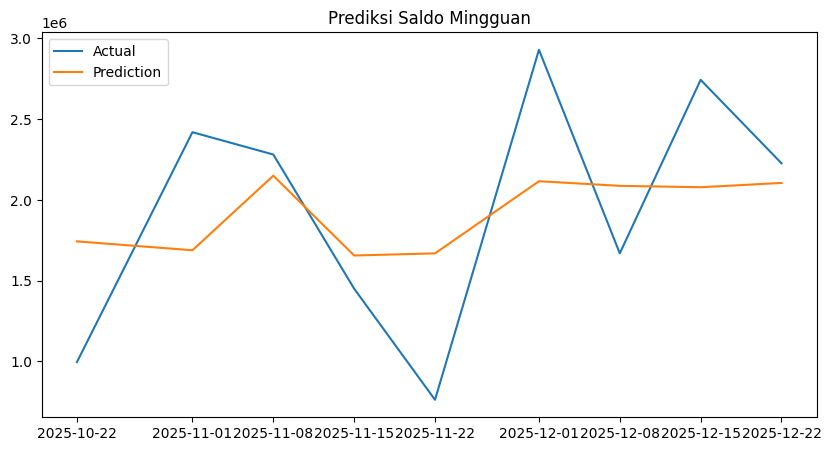

In [12]:
plt.figure(figsize=(10,5))
plt.plot(test['tanggal'], y_test, label='Actual')
plt.plot(test['tanggal'], pred, label='Prediction')
plt.legend()
plt.title("Prediksi Saldo Mingguan")
plt.show()

In [13]:
#test prediksi 1 minggu kedepan
last = df.iloc[-1]

input_pred = np.array([[last['lag_1'],
                        last['lag_2'],
                        last['lag_3'],
                        last['ma_4'],
                        last['bulan'],
                        last['minggu_dalam_bulan']]])

next_week_pred = model.predict(input_pred)[0]
print("Prediksi saldo minggu depan:", int(next_week_pred))

Prediksi saldo minggu depan: 2105339


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [14]:
#prediksi 4 minggu kedepan
def predict_future_weeks(model, df, n_weeks):
    df_temp = df.copy()
    predictions = []

    for i in range(n_weeks):
        last_row = df_temp.iloc[-1]

        # Ambil fitur terakhir
        lag_1 = last_row['saldo']
        lag_2 = df_temp.iloc[-2]['saldo']
        lag_3 = df_temp.iloc[-3]['saldo']
        ma_4 = df_temp['saldo'].tail(4).mean()
        bulan = (last_row['tanggal'] + pd.Timedelta(days=7)).month
        minggu_dalam_bulan = ((last_row['tanggal'] + pd.Timedelta(days=7)).day - 1) // 7 + 1

        X_pred = np.array([[lag_1, lag_2, lag_3, ma_4, bulan, minggu_dalam_bulan]])
        next_pred = model.predict(X_pred)[0]

        # Simpan hasil prediksi
        next_date = last_row['tanggal'] + pd.Timedelta(days=7)
        predictions.append((next_date, next_pred))

        # Tambahkan ke dataframe sementara untuk prediksi berikutnya
        new_row = pd.DataFrame({
            'tanggal': [next_date],
            'saldo': [next_pred]
        })

        df_temp = pd.concat([df_temp, new_row], ignore_index=True)

    return predictions

In [15]:
future_preds = predict_future_weeks(model, df, n_weeks=4)

for tgl, nilai in future_preds:
    print(f"Prediksi {tgl.date()} : Rp {int(nilai):,}")


Prediksi 2025-12-29 : Rp 2,146,401
Prediksi 2026-01-05 : Rp 1,856,989
Prediksi 2026-01-12 : Rp 1,992,763
Prediksi 2026-01-19 : Rp 2,011,985


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


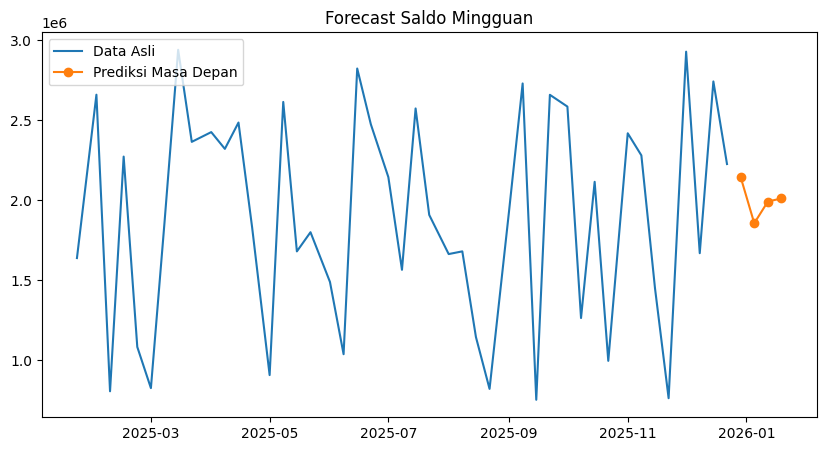

In [16]:
future_df = pd.DataFrame(future_preds, columns=['tanggal', 'prediksi'])

plt.figure(figsize=(10,5))
plt.plot(df['tanggal'], df['saldo'], label='Data Asli')
plt.plot(future_df['tanggal'], future_df['prediksi'], marker='o', label='Prediksi Masa Depan')
plt.legend()
plt.title('Forecast Saldo Mingguan')
plt.show()


In [17]:
# joblib.dump(model, "model_prediksi_saldo_mingguan.pkl")
# files.download("model_prediksi_saldo_mingguan.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>